In [83]:
import typing
import utils
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [84]:
basedir = "../5_task_transfer"

In [85]:
df = utils.subset_data(
    basedir=basedir,
    index={
        # "model.from_pretrained": lambda x: x is not None,
        # "dataset.concurrent_reg": lambda x: x == 5,
    },
)
df.sample(5)

,Unnamed: 0,epoch,run_id,_step,cumAUC,_runtime,best_val_acc,best_val_loss,step,train_loss,...,heldout_items,concurrent_reg,same_diff_prob,concurrent_items,role_n_congruence,heldout_items_per_reg,create_dataset_and_exit,local_split_set_control,global_split_set_control,pretraining_condition
2,2,0.0,happy-sweep-2,0.0,0.000000,7.609528,0.0,inf,0.0,4.656509,...,0,5,0.5,4,0,15,False,NaN,NaN,N-BACK-4
551,551,55.0,electric-sweep-2,21890.0,48.037050,9956.140983,0.0,0.000896,21485.0,0.000612,...,0,2,0.5,4,0,15,False,NaN,NaN,random_init
319,319,31.0,vocal-sweep-2,12338.0,18.356940,3968.401127,0.0,0.622206,12110.0,0.623090,...,0,5,0.5,4,0,15,False,NaN,NaN,random_init
247,247,24.0,scarlet-sweep-4,9552.0,22.171585,3279.921925,0.0,0.000262,9375.0,0.000208,...,0,2,0.5,4,0,15,False,NaN,NaN,random_init
291,291,48.0,noble-sweep-9,19104.0,16.646015,6502.196330,0.0,0.377782,18750.0,NaN,...,0,2,0.5,4,0,15,False,NaN,NaN,random_init


In [86]:
metadata_index = utils.extract_sweep_properties(
    utils.gather_sweeps(basedir),
    ["dataset.td_prob", "dataset.concurrent_reg", "dataset.n_back"],
)
[*metadata_index.items()][0]

('7fpiixi7',
 {'dataset.td_prob': 0, 'dataset.concurrent_reg': 2, 'dataset.n_back': 2})

In [87]:
from typing import Literal


def get_pretraining_condition(row) -> Literal["REF-BACK", "N-BACK", "NA"]:
    this_pretraining = row["from_pretrained"]
    if isinstance(this_pretraining, str):
        pretraining_sweep_id = this_pretraining.split("/")[1]
        this_sweep_metadata = metadata_index[pretraining_sweep_id]
        N = this_sweep_metadata["dataset.n_back"]
        R = this_sweep_metadata["dataset.concurrent_reg"]
        return (
            f"REF-BACK-{R}"
            if this_sweep_metadata["dataset.td_prob"] == 0
            else f"N-BACK-{N}"
        )
    return "random_init"


# map td_prob_info to `df` as a new column called 'pretraining_condition'
df["pretraining_condition"] = df.apply(
    get_pretraining_condition,
    axis=1,
)

df.loc[df["from_pretrained"] == None]["pretraining_condition"] = "random_init"

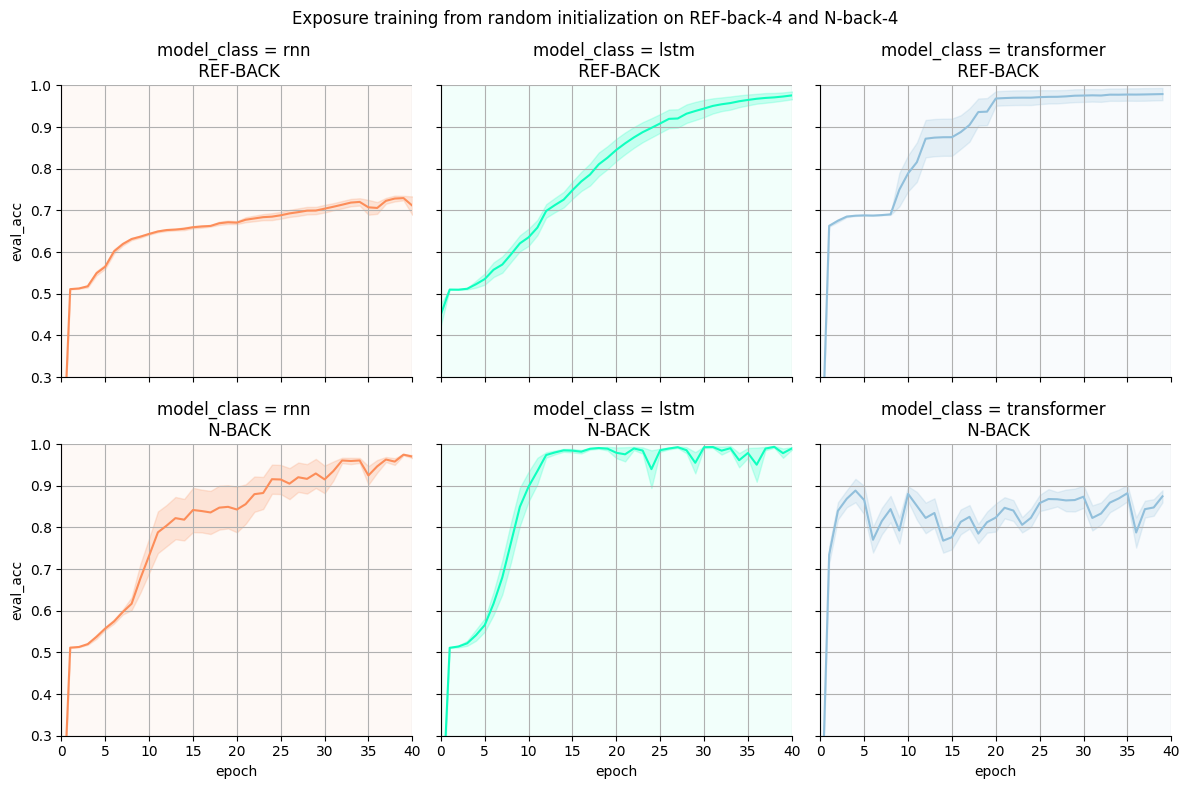

In [88]:
view = df.loc[df["pretraining_condition"] == "random_init"]
view = view.loc[view["n_back"] == 4]
[N] = view.concurrent_reg.unique()


g = sns.FacetGrid(
    view,
    col="model_class",
    row="td_prob",
    hue="model_class",
    sharex=True,
    sharey=True,
    height=4,
    palette=sns.color_palette(this_colors := ["#fc8d59", "#0fffbf", "#91bfdb"]),
)
g.map_dataframe(
    sns.lineplot,
    x="epoch",
    y="eval_acc",
    alpha=1,
    errorbar="se",
)
g.figure.suptitle(
    f"Exposure training from random initialization on REF-back-{N} and N-back-{N}",
    # y=1.05,
)

alpha = 0.05
background_colors = dict(
    zip(
        view.model_class.unique(),
        zip(
            this_colors,
            [alpha] * 10,
        ),
    )
)

for ax in g.axes.flat:
    ax.set_ylim(0.3, 1)
    ax.set_xlim(0, 40)
    ax.set_xticks(np.arange(0, 41, 5))
    ax.grid()

    model_class = ax.get_title().split(" | ")[1].split(" = ")[1]
    if model_class in background_colors:
        ax.set_facecolor(background_colors[model_class])

    td_prob, model_class = ax.get_title().split(" | ")
    if int(td_prob.split("=")[1]) == 1:
        ax.set_title(f"{model_class} \n N-BACK")
    else:
        ax.set_title(f"{model_class} \n REF-BACK")


plt.tight_layout()
# g.add_legend()
plt.show()

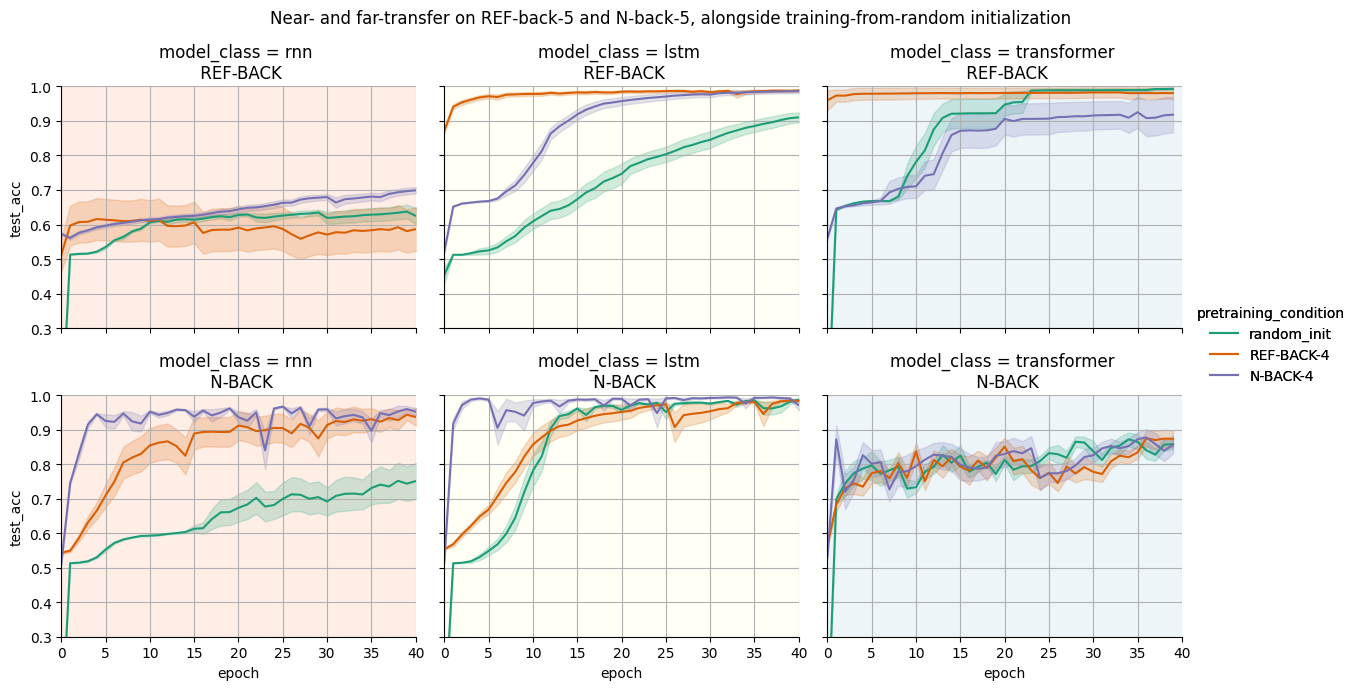

In [91]:
view = df.loc[df.concurrent_reg == 5]
[R] = view.concurrent_reg.unique()
[N] = view.n_back.unique()
assert N == R


def shuffled(collection: typing.Collection):
    import random

    return random.sample(collection, len(collection))
    # Define a mapping of model_class to colors


g = sns.FacetGrid(
    view,
    col="model_class",
    row="td_prob",
    hue="pretraining_condition",
    sharex=True,
    sharey=True,
    height=3.5,
    palette=sns.color_palette(["#1b9e77", "#d95f02", "#7570b3"]),
)
g.map_dataframe(
    sns.lineplot,
    x="epoch",
    y="test_acc",
    alpha=1,
    errorbar="se",
)
g.figure.suptitle(
    f"Near- and far-transfer on REF-back-{N} and N-back-{N}, alongside training-from-random initialization",
    # y=1.05,
)


alpha = 0.15
background_colors = dict(
    zip(
        view.model_class.unique(),
        zip(
            ["#fc8d59", "#ffffbf", "#91bfdb"],
            [alpha] * 10,
        ),
    )
)

# Apply background color to each subplot based on model_class


g.add_legend()
for ax in g.axes.flat:
    ax.set_ylim(0.3, 1)
    ax.set_xlim(0, 40)
    ax.set_xticks(np.arange(0, 41, 5))
    ax.grid()

    model_class = ax.get_title().split(" | ")[1].split(" = ")[1]
    if model_class in background_colors:
        ax.set_facecolor(background_colors[model_class])

    td_prob, model_class = ax.get_title().split(" | ")
    if int(td_prob.split("=")[1]) == 1:
        ax.set_title(f"{model_class} \n N-BACK")
    else:
        ax.set_title(f"{model_class} \n REF-BACK")


plt.tight_layout()
g.add_legend()
plt.show()

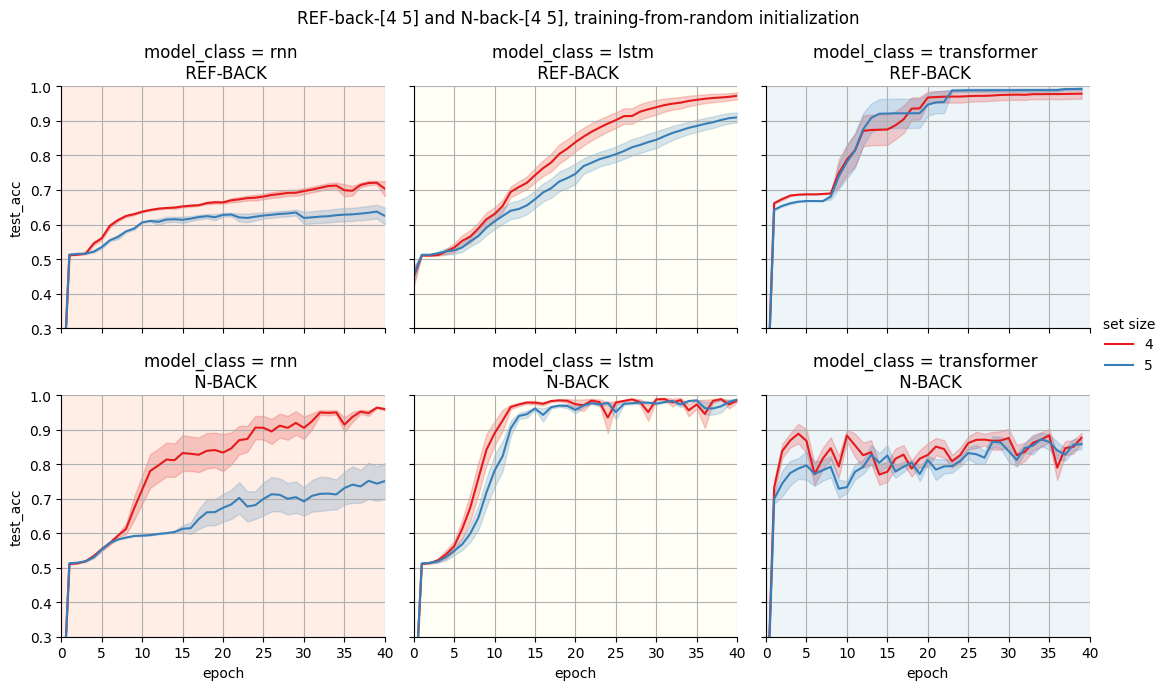

In [112]:
view = df.loc[df.concurrent_reg.isin((4, 5))]
view = view.loc[view.pretraining_condition == "random_init"]
R = view.concurrent_reg.unique()
N = view.n_back.unique()


def shuffled(collection: typing.Collection):
    import random

    return random.sample(collection, len(collection))
    # Define a mapping of model_class to colors


g = sns.FacetGrid(
    view,
    col="model_class",
    row="td_prob",
    hue="n_back",
    sharex=True,
    sharey=True,
    height=3.5,
    palette="Set1",
)
g.map_dataframe(
    sns.lineplot,
    x="epoch",
    y="test_acc",
    alpha=1,
    errorbar="se",
)
g.figure.suptitle(
    f"REF-back-{N} and N-back-{N}, training-from-random initialization",
    # y=1.05,
)


alpha = 0.15
background_colors = dict(
    zip(
        view.model_class.unique(),
        zip(
            ["#fc8d59", "#ffffbf", "#91bfdb"],
            [alpha] * 10,
        ),
    )
)

# Apply background color to each subplot based on model_class


g.add_legend()
for ax in g.axes.flat:
    ax.set_ylim(0.3, 1)
    ax.set_xlim(0, 40)
    ax.set_xticks(np.arange(0, 41, 5))
    ax.grid()

    model_class = ax.get_title().split(" | ")[1].split(" = ")[1]
    if model_class in background_colors:
        ax.set_facecolor(background_colors[model_class])

    td_prob, model_class = ax.get_title().split(" | ")
    if int(td_prob.split("=")[1]) == 1:
        ax.set_title(f"{model_class} \n N-BACK")
    else:
        ax.set_title(f"{model_class} \n REF-BACK")

g._legend.remove()
plt.tight_layout()
g.add_legend(title="set size")
plt.show()